<a href="https://colab.research.google.com/github/DaniloRamosA/AmigoSecreto/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [10]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [13]:
# Agregamos una columna que indique la tienda de origen
tienda['Tienda'] = 'Tienda 1'
tienda2['Tienda'] = 'Tienda 2'
tienda3['Tienda'] = 'Tienda 3'
tienda4['Tienda'] = 'Tienda 4'

# Unimos todas las tiendas en un solo DataFrame
tiendas = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)
# Convertimos fechas y números
tiendas['Fecha de Compra'] = pd.to_datetime(tiendas['Fecha de Compra'], dayfirst=True)
tiendas['Precio'] = pd.to_numeric(tiendas['Precio'], errors='coerce')
tiendas['Costo de envío'] = pd.to_numeric(tiendas['Costo de envío'], errors='coerce')

# Calculamos ingresos y ganancias
tiendas['Ingreso'] = tiendas['Precio']
tiendas['Ganancia'] = tiendas['Precio'] - tiendas['Costo de envío']

total_ingresos = tiendas['Ingreso'].sum()
total_ganancia = tiendas['Ganancia'].sum()

print(f"💵 Ingreso total: ${total_ingresos:,.0f}")
print(f"🤑 Ganancia total: ${total_ganancia:,.0f}")




💵 Ingreso total: $4,403,619,200
🤑 Ganancia total: $4,168,922,200


<ipython-input-22-959c70489272>:8: UserWarning: Glyph 128188 (\N{BRIEFCASE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128188 (\N{BRIEFCASE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


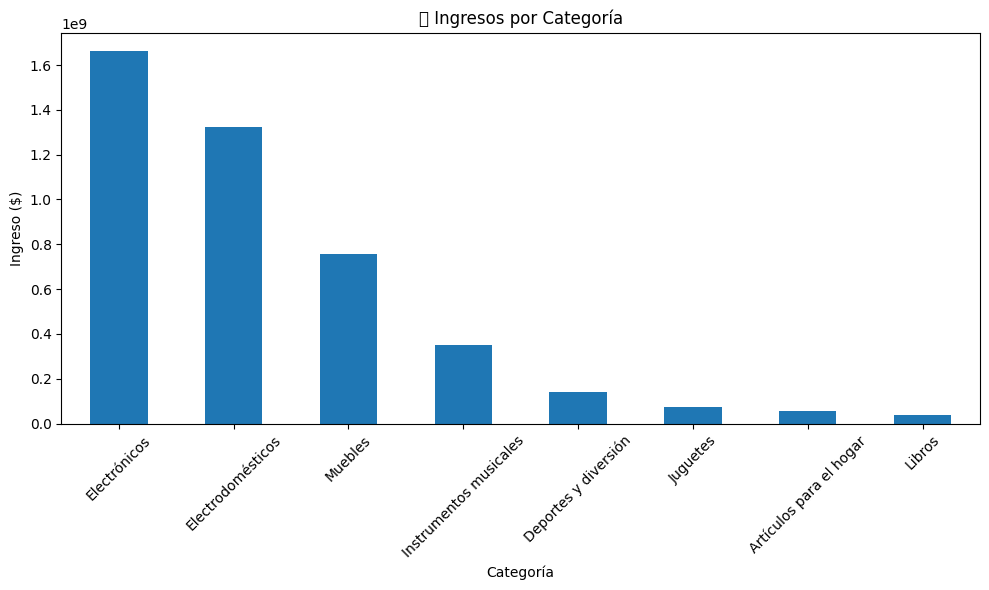

<ipython-input-22-959c70489272>:16: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


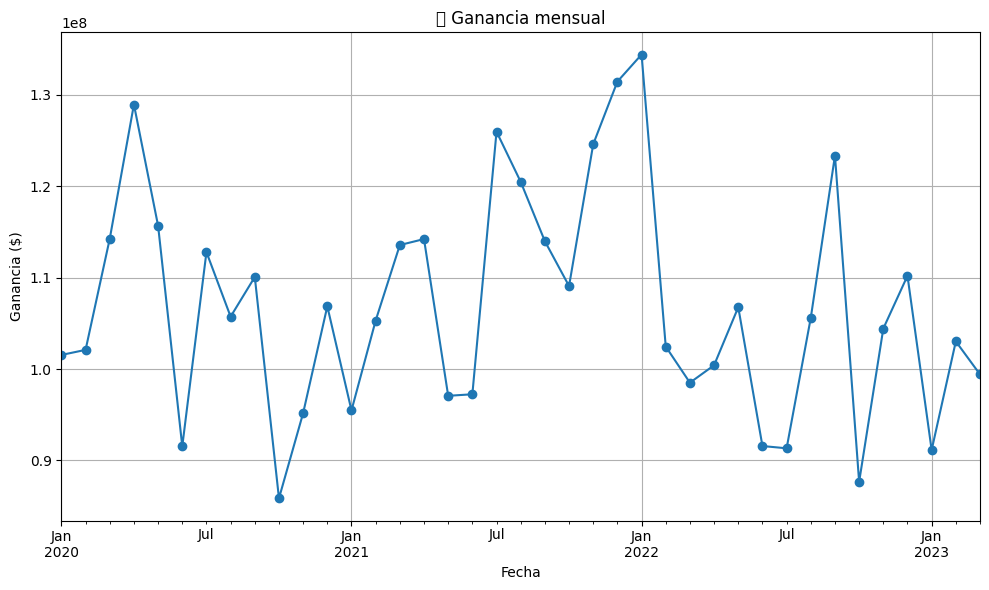

In [22]:
import matplotlib.pyplot as plt

# Ingresos por categoría
ventas_categoria['Ingreso'].plot(kind='bar', figsize=(10,6), title='💼 Ingresos por Categoría')
plt.ylabel('Ingreso ($)')
plt.xlabel('Categoría')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Ganancia mensual
ventas_mensual['Ganancia'].plot(kind='line', marker='o', figsize=(10,6), title='📅 Ganancia mensual')
plt.ylabel('Ganancia ($)')
plt.xlabel('Fecha')
plt.grid(True)
plt.tight_layout()
plt.show()


# 2. Ventas por categoría

In [14]:
ventas_categoria = tiendas.groupby('Categoría del Producto')[['Ingreso', 'Ganancia']].sum().sort_values(by='Ingreso', ascending=False)
print(ventas_categoria)


                              Ingreso      Ganancia
Categoría del Producto                             
Electrónicos             1.660576e+09  1.572114e+09
Electrodomésticos        1.324751e+09  1.254355e+09
Muebles                  7.576610e+08  7.172106e+08
Instrumentos musicales   3.487726e+08  3.302683e+08
Deportes y diversión     1.429777e+08  1.352861e+08
Juguetes                 7.360440e+07  6.958310e+07
Artículos para el hogar  5.757980e+07  5.446870e+07
Libros                   3.769610e+07  3.563620e+07


# 3. Calificación promedio de la tienda


In [16]:
# Calificación promedio por tienda
calificacion_promedio = tiendas.groupby('Tienda')['Calificación'].mean().sort_values(ascending=False)

# Mostrar resultados
print(calificacion_promedio)


Tienda
Tienda 3    4.048326
Tienda 2    4.037304
Tienda 4    3.995759
Tienda 1    3.976685
Name: Calificación, dtype: float64


<ipython-input-21-84a32f234582>:6: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


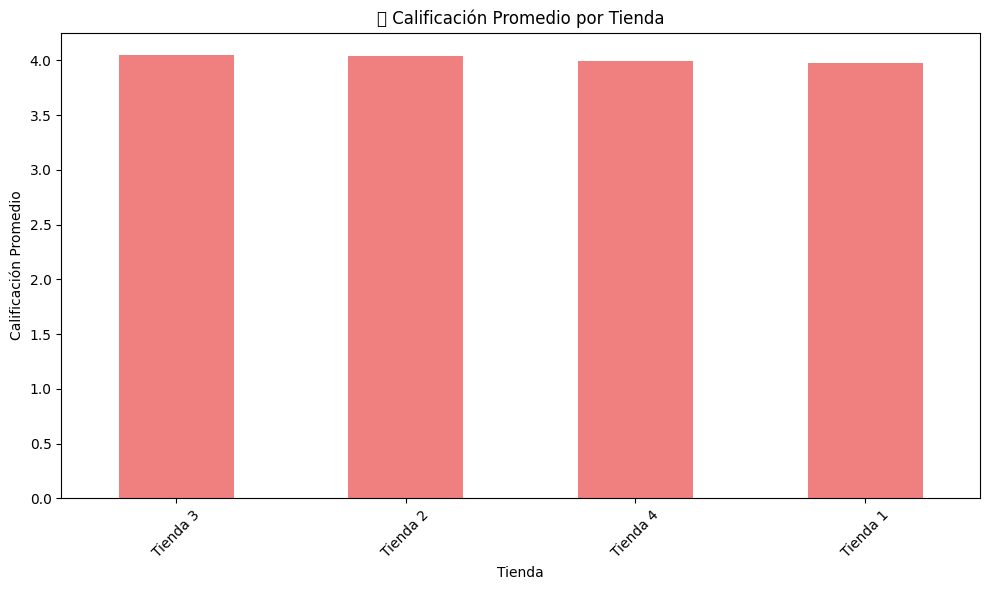

In [21]:
# Visualización de la calificación promedio por tienda
calificacion_promedio.plot(kind='bar', figsize=(10,6), color='lightcoral', title='📊 Calificación Promedio por Tienda')
plt.ylabel('Calificación Promedio')
plt.xlabel('Tienda')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 4. Productos más y menos vendidos

In [17]:
# Productos más vendidos (sumando las cuotas)
productos_mas_vendidos = tiendas.groupby('Producto')['Cantidad de cuotas'].sum().sort_values(ascending=False)

# Productos menos vendidos
productos_menos_vendidos = tiendas.groupby('Producto')['Cantidad de cuotas'].sum().sort_values(ascending=True)

# Mostrar resultados
print("🔝 Productos más vendidos:")
print(productos_mas_vendidos.head(10))  # Muestra los 10 más vendidos
print("\n🔻 Productos menos vendidos:")
print(productos_menos_vendidos.head(10))  # Muestra los 10 menos vendidos


🔝 Productos más vendidos:
Producto
Secadora de ropa     649
Mesa de noche        627
Pandereta            625
Bicicleta            614
Iphone 15            611
Cama king            603
Set de ollas         601
Microondas           600
Guitarra acústica    595
Batería              595
Name: Cantidad de cuotas, dtype: int64

🔻 Productos menos vendidos:
Producto
Smartwatch            432
Set de vasos          435
Celular ABXY          447
Dinosaurio Rex        458
Mesa de centro        469
Mochila               471
Muñeca bebé           474
Cubo mágico 8x8       487
Guitarra eléctrica    497
Tablet ABXY           497
Name: Cantidad de cuotas, dtype: int64


<ipython-input-20-1a4eb96ea1d9>:6: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


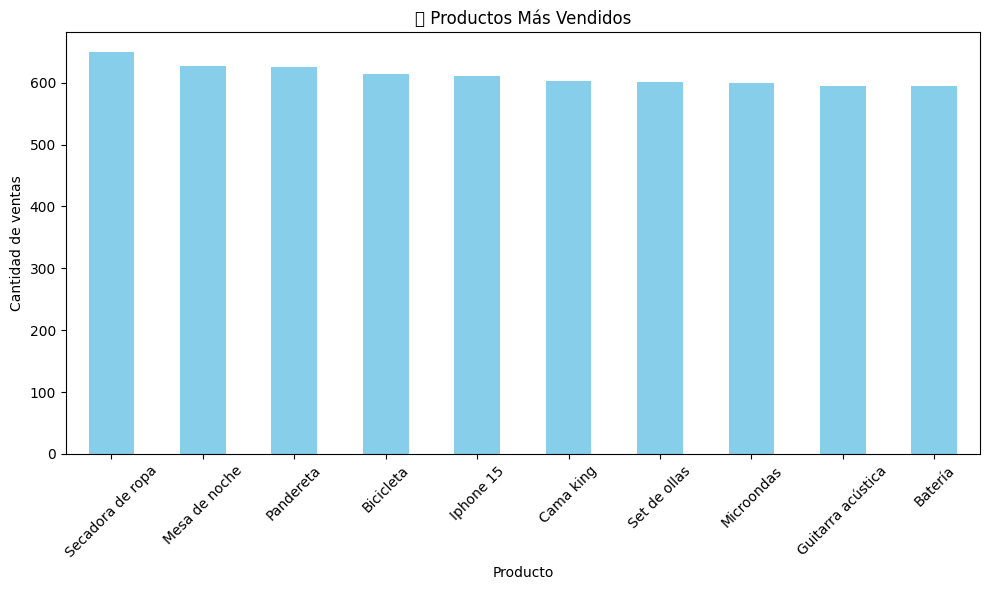

<ipython-input-20-1a4eb96ea1d9>:14: UserWarning: Glyph 128315 (\N{DOWN-POINTING RED TRIANGLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128315 (\N{DOWN-POINTING RED TRIANGLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


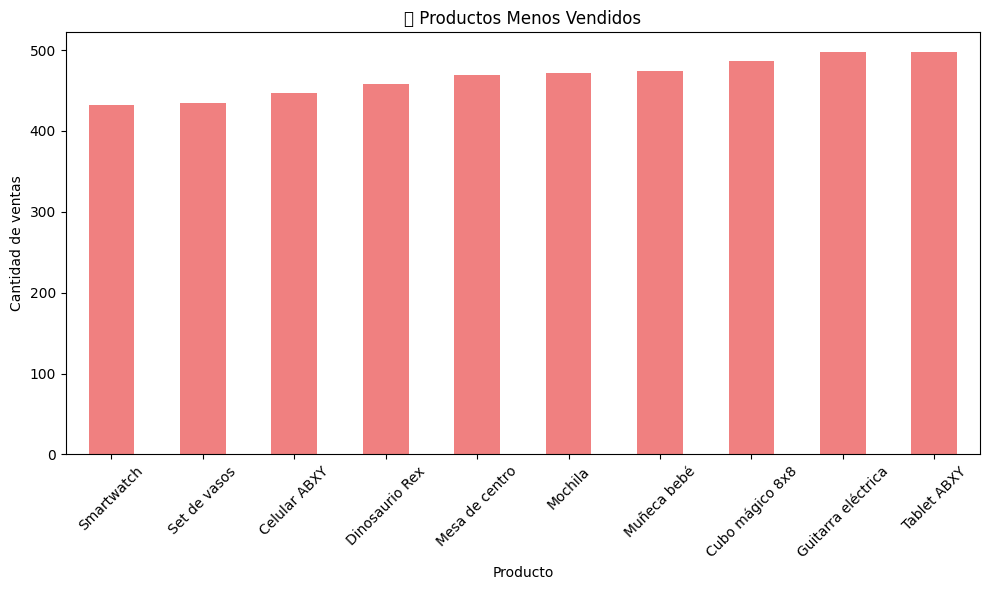

In [20]:
# Visualización de los 10 productos más vendidos
productos_mas_vendidos.head(10).plot(kind='bar', figsize=(10,6), color='skyblue', title='🔝 Productos Más Vendidos')
plt.ylabel('Cantidad de ventas')
plt.xlabel('Producto')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualización de los 10 productos menos vendidos
productos_menos_vendidos.head(10).plot(kind='bar', figsize=(10,6), color='lightcoral', title='🔻 Productos Menos Vendidos')
plt.ylabel('Cantidad de ventas')
plt.xlabel('Producto')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 5. Envío promedio por tienda

In [18]:
# Cálculo del costo promedio de envío por tienda
envio_promedio = tiendas.groupby('Tienda')['Costo de envío'].mean().sort_values(ascending=True)

# Mostrar resultados
print("💸 Costo promedio de envío por tienda:")
print(envio_promedio)


💸 Costo promedio de envío por tienda:
Tienda
Tienda 4    23459.457167
Tienda 3    24805.680373
Tienda 2    25216.235693
Tienda 1    26018.609580
Name: Costo de envío, dtype: float64


<ipython-input-19-f1092790918a>:6: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


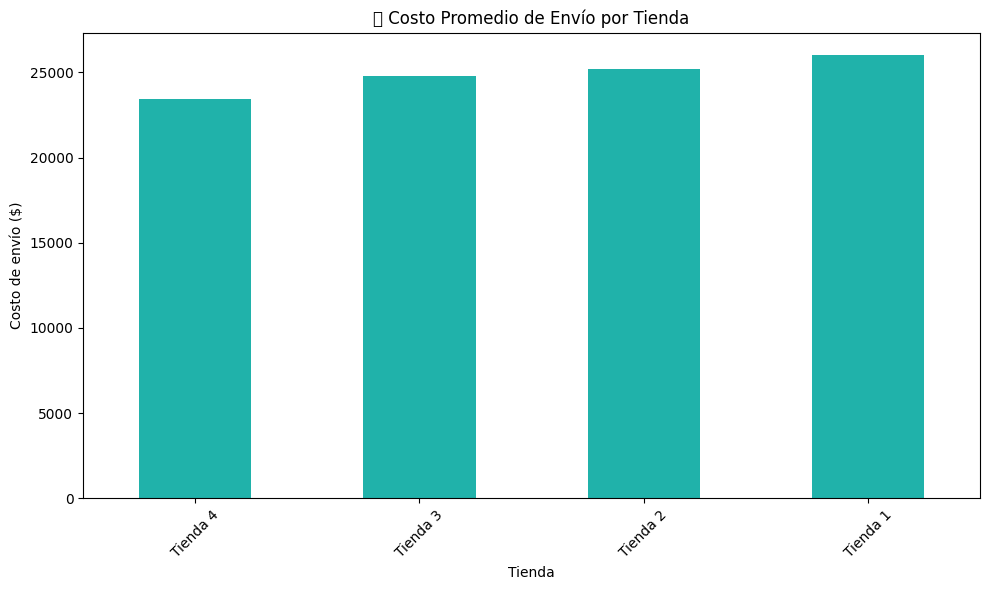

In [19]:
# Visualización del costo promedio de envío por tienda
envio_promedio.plot(kind='bar', figsize=(10,6), color='lightseagreen', title='💸 Costo Promedio de Envío por Tienda')
plt.ylabel('Costo de envío ($)')
plt.xlabel('Tienda')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
